# Phase 2 — Exploration des données et modélisation ML
## Prédiction de la production d'énergie solaire au Maroc

Ce notebook explore le dataset collecté en Phase 1 (PVGIS + Open-Meteo), puis entraîne et compare deux modèles de prédiction de la production solaire horaire :
- **Random Forest** (baseline robuste)
- **XGBoost** (souvent plus performant sur ce type de données tabulaires)

**Avant de commencer** : modifie la variable `VILLE` ci-dessous selon le fichier CSV que tu veux analyser (`Beni_Mellal`, `Ouarzazate`, ou `Casablanca`).

In [52]:
# Installation (si besoin, décommente la ligne suivante)
# !pip install pandas scikit-learn xgboost matplotlib seaborn --break-system-packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.rcParams["figure.figsize"] = (10, 4)

## 1. Chargement des données

In [53]:
VILLE = "Casablanca"  # change ici : Beni_Mellal, Ouarzazate, ou Casablanca

df = pd.read_csv(f"data/{VILLE}_dataset_solaire.csv", parse_dates=["datetime_local_maroc"])
print(f"Nombre de lignes : {len(df)}")
print(f"Colonnes : {list(df.columns)}")
df.head()

Nombre de lignes : 8784
Colonnes : ['datetime_local_maroc', 'mois', 'jour_semaine', 'heure', 'jour_annee', 'irradiance_wm2', 'temperature_c', 'nebulosite_pct', 'humidite_pct', 'vent_kmh', 'production_kwh']


,datetime_local_maroc,mois,jour_semaine,heure,jour_annee,irradiance_wm2,temperature_c,nebulosite_pct,humidite_pct,vent_kmh,production_kwh
0,2020-01-01 01:00:00,1,2,1,1,0.0,9.49,0,94,5.8,0.0
1,2020-01-01 02:00:00,1,2,2,1,0.0,8.95,0,93,5.8,0.0
2,2020-01-01 03:00:00,1,2,3,1,0.0,8.54,0,91,6.1,0.0
3,2020-01-01 04:00:00,1,2,4,1,0.0,8.36,0,90,7.6,0.0
4,2020-01-01 05:00:00,1,2,5,1,0.0,8.34,0,91,9.4,0.0


## 2. Exploration des données (EDA)

On vérifie d'abord la qualité des données (valeurs manquantes, statistiques descriptives), puis on visualise les patterns clés.

In [54]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

print("\nStatistiques descriptives :")
df.describe()

Valeurs manquantes par colonne :
datetime_local_maroc    0
mois                    0
jour_semaine            0
heure                   0
jour_annee              0
irradiance_wm2          0
temperature_c           0
nebulosite_pct          0
humidite_pct            0
vent_kmh                0
production_kwh          0
dtype: int64

Statistiques descriptives :


,datetime_local_maroc,mois,jour_semaine,heure,jour_annee,irradiance_wm2,temperature_c,nebulosite_pct,humidite_pct,vent_kmh,production_kwh
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2020-07-02 00:23:06.885246,6.513547,2.997495,11.500000,183.495219,259.209641,18.743704,42.625683,77.864413,10.172211,0.199264
min,2020-01-01 01:00:00,1.000000,0.000000,0.000000,1.000000,0.000000,5.130000,0.000000,18.000000,0.400000,0.000000
25%,2020-04-01 12:45:00,4.000000,1.000000,5.750000,92.000000,0.000000,14.640000,1.000000,67.000000,6.300000,0.000000
50%,2020-07-02 00:30:00,7.000000,3.000000,11.500000,183.500000,0.000000,18.460000,35.000000,80.000000,9.300000,0.000000
75%,2020-10-01 12:15:00,10.000000,5.000000,17.250000,275.000000,534.530000,22.050000,85.000000,91.000000,13.400000,0.422108
max,2021-01-01 00:00:00,12.000000,6.000000,23.000000,366.000000,1141.270000,40.120000,100.000000,100.000000,41.900000,0.891720
std,NaN,3.451497,1.995325,6.922581,105.663095,350.850845,5.451525,38.632554,14.788561,5.260440,0.271407


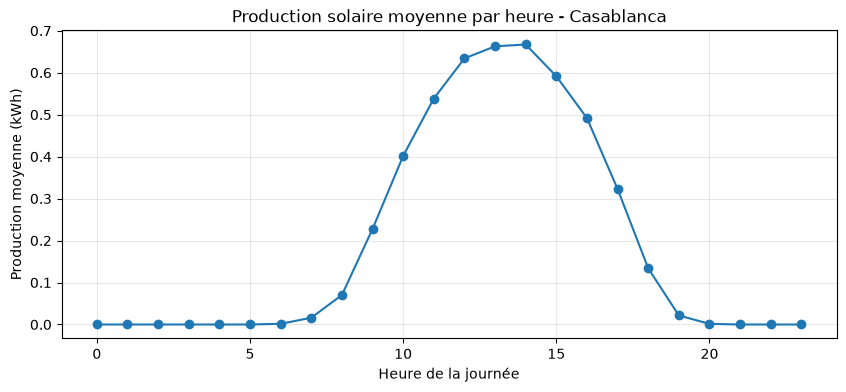

In [55]:
# Production solaire moyenne par heure de la journée (doit suivre le cycle jour/nuit)
production_par_heure = df.groupby("heure")["production_kwh"].mean()

plt.figure()
plt.plot(production_par_heure.index, production_par_heure.values, marker="o")
plt.xlabel("Heure de la journée")
plt.ylabel("Production moyenne (kWh)")
plt.title(f"Production solaire moyenne par heure - {VILLE}")
plt.grid(True, alpha=0.3)
plt.show()

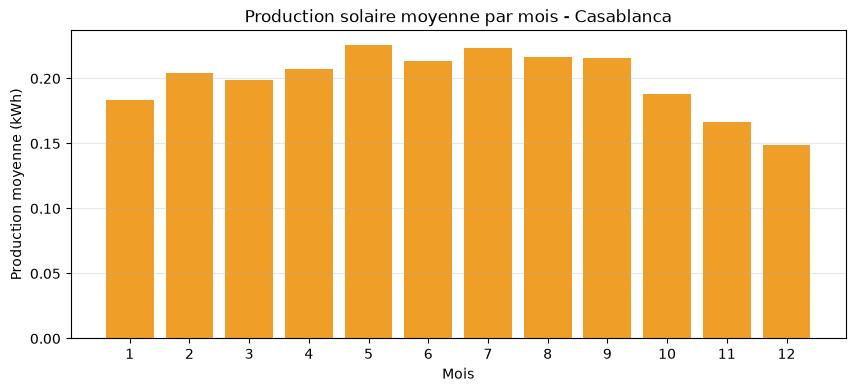

In [56]:
# Production solaire moyenne par mois (doit suivre la saisonnalité)
production_par_mois = df.groupby("mois")["production_kwh"].mean()

plt.figure()
plt.bar(production_par_mois.index, production_par_mois.values, color="#EF9F27")
plt.xlabel("Mois")
plt.ylabel("Production moyenne (kWh)")
plt.title(f"Production solaire moyenne par mois - {VILLE}")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3, axis="y")
plt.show()

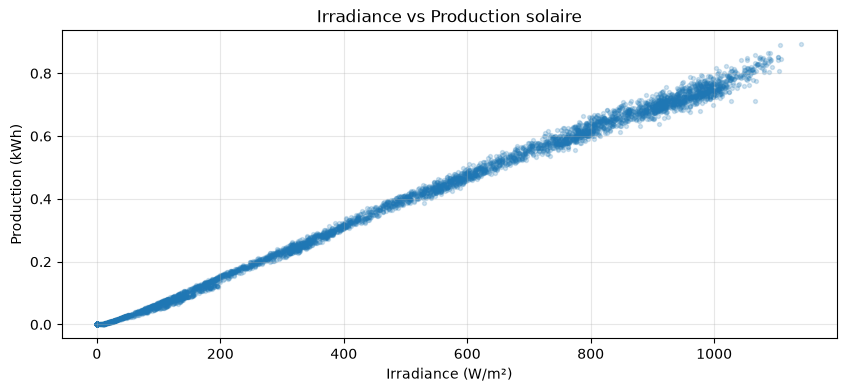

Corrélation de chaque variable avec la production :
production_kwh    1.000000
irradiance_wm2    0.999090
temperature_c     0.527001
vent_kmh          0.384517
nebulosite_pct   -0.177331
humidite_pct     -0.722624
Name: production_kwh, dtype: float64


In [57]:
# Relation entre irradiance et production (doit être fortement corrélée)
plt.figure()
plt.scatter(df["irradiance_wm2"], df["production_kwh"], alpha=0.2, s=8)
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Production (kWh)")
plt.title("Irradiance vs Production solaire")
plt.grid(True, alpha=0.3)
plt.show()

correlation = df[["irradiance_wm2", "temperature_c", "nebulosite_pct", "humidite_pct", "vent_kmh", "production_kwh"]].corr()["production_kwh"]
print("Corrélation de chaque variable avec la production :")
print(correlation.sort_values(ascending=False))

## 3. Préparation des données pour le modèle

On sépare les features (X) de la cible (y = production_kwh), puis on fait un split train/test.

**Important** : pour des données temporelles, on évite un split aléatoire classique qui mélangerait le passé et le futur. On utilise donc un split chronologique (les derniers 20% de l'année servent de test).

In [58]:
features = ["mois", "jour_semaine", "heure", "jour_annee", "irradiance_wm2", "temperature_c", "nebulosite_pct", "humidite_pct", "vent_kmh"]
cible = "production_kwh"

df = df.sort_values("datetime_local_maroc").reset_index(drop=True)

X = df[features]
y = df[cible]

# Split chronologique : 80% pour l'entraînement (début d'année), 20% pour le test (fin d'année)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Taille entraînement : {len(X_train)} lignes")
print(f"Taille test : {len(X_test)} lignes")

Taille entraînement : 7027 lignes
Taille test : 1757 lignes


## 4. Modèle 1 — Random Forest (baseline)

In [59]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"MAE  : {mae_rf:.4f} kWh")
print(f"RMSE : {rmse_rf:.4f} kWh")
print(f"R²   : {r2_rf:.4f}")

=== Random Forest ===
MAE  : 0.0027 kWh
RMSE : 0.0055 kWh
R²   : 0.9995


## 5. Modèle 2 — XGBoost

In [60]:
xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"MAE  : {mae_xgb:.4f} kWh")
print(f"RMSE : {rmse_xgb:.4f} kWh")
print(f"R²   : {r2_xgb:.4f}")

=== XGBoost ===
MAE  : 0.0022 kWh
RMSE : 0.0043 kWh
R²   : 0.9997


## 6. Comparaison visuelle : prédiction vs réalité

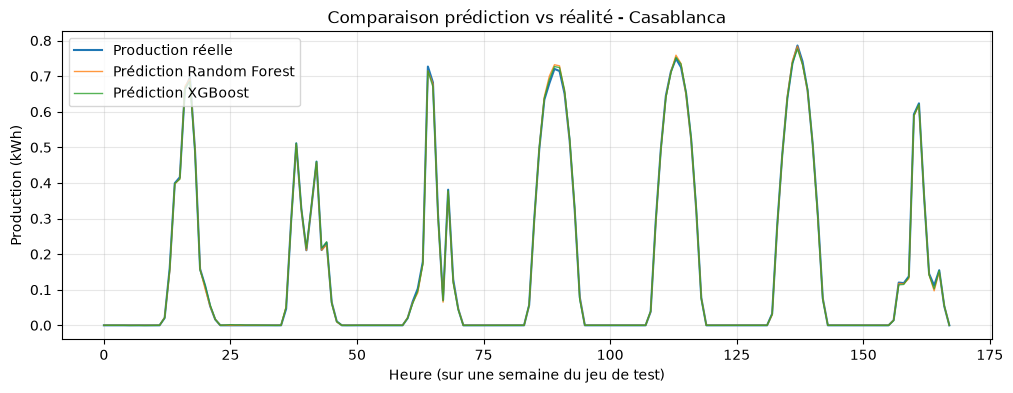

In [61]:
# Zoom sur une semaine du jeu de test pour bien visualiser la qualité de la prédiction
n_heures_affichees = 24 * 7  # une semaine

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:n_heures_affichees], label="Production réelle", linewidth=1.5)
plt.plot(y_pred_rf[:n_heures_affichees], label="Prédiction Random Forest", linewidth=1, alpha=0.8)
plt.plot(y_pred_xgb[:n_heures_affichees], label="Prédiction XGBoost", linewidth=1, alpha=0.8)
plt.xlabel("Heure (sur une semaine du jeu de test)")
plt.ylabel("Production (kWh)")
plt.title(f"Comparaison prédiction vs réalité - {VILLE}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Importance des variables (XGBoost)

Quelles variables influencent le plus la prédiction ? Ça permet de justifier tes choix de features dans ton rapport.

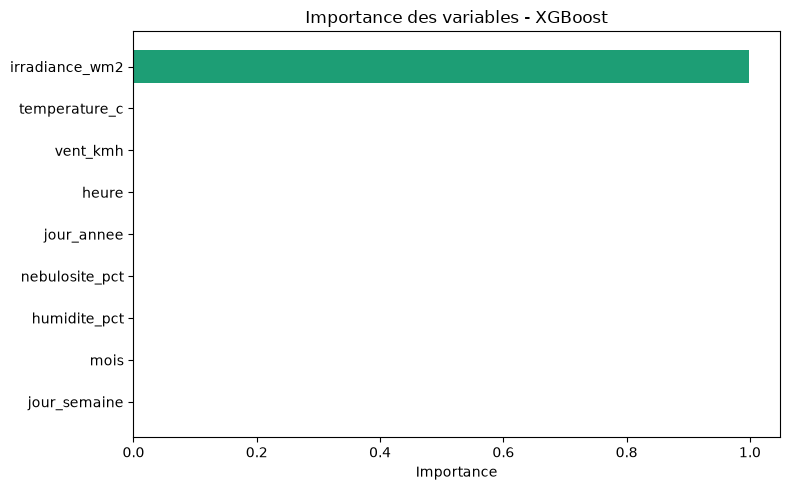

irradiance_wm2    0.998852
temperature_c     0.000497
vent_kmh          0.000281
heure             0.000118
jour_annee        0.000100
nebulosite_pct    0.000051
humidite_pct      0.000043
mois              0.000034
jour_semaine      0.000024
dtype: float32


In [62]:
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color="#1D9E75")
plt.xlabel("Importance")
plt.title("Importance des variables - XGBoost")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

## 8. Sauvegarde du meilleur modèle

On sauvegarde le modèle entraîné pour pouvoir le réutiliser dans l'API (Phase 3).

In [63]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Choisis le modèle avec le meilleur R² / RMSE d'après tes résultats ci-dessus
meilleur_modele = xgb_model if rmse_xgb < rmse_rf else rf_model
nom_modele = "xgboost" if rmse_xgb < rmse_rf else "random_forest"

joblib.dump(meilleur_modele, f"models/modele_solaire_{VILLE}_{nom_modele}.pkl")
print(f"Modèle sauvegardé : models/modele_solaire_{VILLE}_{nom_modele}.pkl")
print(f"(RMSE Random Forest = {rmse_rf:.4f} | RMSE XGBoost = {rmse_xgb:.4f})")

Modèle sauvegardé : models/modele_solaire_Casablanca_xgboost.pkl
(RMSE Random Forest = 0.0055 | RMSE XGBoost = 0.0043)


## Résumé et prochaines étapes

- Le modèle est entraîné et évalué avec un split chronologique (réaliste pour des séries temporelles).
- `irradiance_wm2` devrait ressortir comme la variable la plus importante (logique physiquement).
- **Prochaine étape (Phase 3)** : exposer ce modèle sauvegardé via une API Flask/Django avec un endpoint `/predict-production`.

## 9. Vers un vrai problème de prévision (sans irradiance mesurée)

**Pourquoi cette section est importante** : le modèle ci-dessus utilise `irradiance_wm2` comme feature. Or PVGIS calcule la production **directement** à partir de l'irradiance via une formule physique quasi-déterministe (corrélation ≈ 0.998) — le modèle ne fait donc que retrouver cette formule, ce qui n'est pas un vrai exercice de Machine Learning.

**Le vrai problème métier** : en pratique, un opérateur (ONEE, MASEN) ne connaît pas l'irradiance de demain — il n'a accès qu'aux **prévisions météo classiques** (température, nébulosité, humidité, vent), fournies un jour à l'avance par les services météorologiques.

On refait donc l'entraînement **sans irradiance**, pour simuler un vrai scénario de prévision J-1 (day-ahead forecasting).

In [64]:
# Features SANS irradiance : uniquement ce qu'on connaîtrait réellement à l'avance
features_prevision = ["mois", "jour_semaine", "heure", "jour_annee", "temperature_c", "nebulosite_pct", "humidite_pct", "vent_kmh"]

X_prev = df[features_prevision]
y_prev = df[cible]

X_prev_train, X_prev_test = X_prev.iloc[:split_index], X_prev.iloc[split_index:]
y_prev_train, y_prev_test = y_prev.iloc[:split_index], y_prev.iloc[split_index:]

xgb_prevision = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_prevision.fit(X_prev_train, y_prev_train)

y_pred_prev = xgb_prevision.predict(X_prev_test)

mae_prev = mean_absolute_error(y_prev_test, y_pred_prev)
rmse_prev = mean_squared_error(y_prev_test, y_pred_prev) ** 0.5
r2_prev = r2_score(y_prev_test, y_pred_prev)

print("=== XGBoost SANS irradiance (vrai scenario de prevision J-1) ===")
print(f"MAE  : {mae_prev:.4f} kWh")
print(f"RMSE : {rmse_prev:.4f} kWh")
print(f"R2   : {r2_prev:.4f}")
print()
print("Comparaison avec le modele precedent (avec irradiance, donc quasi-triviale) :")
print(f"  Avec irradiance    -> RMSE = {rmse_xgb:.4f} | R2 = {r2_xgb:.4f}")
print(f"  Sans irradiance    -> RMSE = {rmse_prev:.4f} | R2 = {r2_prev:.4f}")

=== XGBoost SANS irradiance (vrai scenario de prevision J-1) ===
MAE  : 0.0572 kWh
RMSE : 0.0994 kWh
R2   : 0.8335

Comparaison avec le modele precedent (avec irradiance, donc quasi-triviale) :
  Avec irradiance    -> RMSE = 0.0043 | R2 = 0.9997
  Sans irradiance    -> RMSE = 0.0994 | R2 = 0.8335


**Comment interpréter la baisse du R²** : c'est normal et attendu. Ce nouveau score reflète la vraie difficulté du problème de prévision (sans connaître l'irradiance exacte à l'avance). C'est ce chiffre-là qu'il faut mettre en avant dans ton rapport comme performance réelle du système, en expliquant clairement la différence entre les deux scénarios :

- **Modèle 1 (avec irradiance)** : utile pour du *monitoring en temps réel* (on mesure l'irradiance actuelle, on en déduit la production instantanée).
- **Modèle 2 (sans irradiance)** : utile pour la *prévision J-1* (on utilise uniquement la météo prévue, cas d'usage réel pour un opérateur réseau).

In [65]:
# Sauvegarde du modele de prevision (le plus utile pour l'API en Phase 3)
joblib.dump(xgb_prevision, f"models/modele_prevision_{VILLE}_xgboost.pkl")
print(f"Modele de prevision sauvegarde : models/modele_prevision_{VILLE}_xgboost.pkl")

Modele de prevision sauvegarde : models/modele_prevision_Casablanca_xgboost.pkl


## 10. Validation croisée temporelle et optimisation d'hyperparamètres

**Pourquoi cette section améliore le projet** : jusqu'ici, le modèle a été évalué avec **un seul découpage** train/test (80% / 20%). Le score obtenu peut dépendre en partie du hasard — si les derniers mois de l'année testés étaient particulièrement faciles ou difficiles à prédire, le score ne reflète pas fidèlement la vraie performance du modèle.

**La méthode plus rigoureuse** : la **validation croisée temporelle** (`TimeSeriesSplit`). Le principe : on teste le modèle sur plusieurs découpages différents dans le temps (toujours en respectant l'ordre chronologique — on n'entraîne jamais sur le futur pour prédire le passé), puis on moyenne les résultats. Ça donne une estimation beaucoup plus fiable de la vraie performance.

**En plus**, on utilise `RandomizedSearchCV` pour tester automatiquement plusieurs combinaisons de réglages internes du modèle (hyperparamètres), au lieu de les avoir choisis à la main comme précédemment (`n_estimators=300, max_depth=6, learning_rate=0.05`).

In [66]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import numpy as np

# On repart des features SANS irradiance (le scenario de prevision realiste, section 9)
X_cv = df[features_prevision]
y_cv = df[cible]

# TimeSeriesSplit : decoupe les donnees en plusieurs blocs chronologiques successifs
# (contrairement a un split aleatoire classique, qui melangerait passe et futur)
tscv = TimeSeriesSplit(n_splits=5)

# Grille de combinaisons a tester pour trouver les meilleurs hyperparametres
grille_parametres = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

recherche = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=grille_parametres,
    n_iter=25,                     # nombre de combinaisons testees (compromis vitesse/qualite)
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

recherche.fit(X_cv, y_cv)

print("Meilleurs hyperparametres trouves :")
print(recherche.best_params_)
print(f"\nMeilleur RMSE moyen (validation croisee) : {-recherche.best_score_:.4f} kWh")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Meilleurs hyperparametres trouves :
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Meilleur RMSE moyen (validation croisee) : 0.0892 kWh


**Comment lire ce résultat** : le RMSE affiché est maintenant une **moyenne sur 5 découpages différents** de l'année, pas juste un seul test — c'est une estimation beaucoup plus robuste et honnête de la performance réelle du modèle.

In [67]:
# Comparaison avec le modele precedent (un seul split, hyperparametres choisis a la main)
meilleur_modele_cv = recherche.best_estimator_

y_pred_cv = meilleur_modele_cv.predict(X_prev_test)
rmse_cv = mean_squared_error(y_prev_test, y_pred_cv) ** 0.5
r2_cv_final = r2_score(y_prev_test, y_pred_cv)

print("=== Comparaison des deux approches (sur le meme jeu de test final) ===")
print(f"Modele precedent (hyperparametres manuels)     -> RMSE = {rmse_prev:.4f} | R2 = {r2_prev:.4f}")
print(f"Modele optimise (validation croisee + recherche) -> RMSE = {rmse_cv:.4f} | R2 = {r2_cv_final:.4f}")

amelioration_pct = (rmse_prev - rmse_cv) / rmse_prev * 100
print(f"\nAmelioration du RMSE : {amelioration_pct:+.1f}%")

=== Comparaison des deux approches (sur le meme jeu de test final) ===
Modele precedent (hyperparametres manuels)     -> RMSE = 0.0994 | R2 = 0.8335
Modele optimise (validation croisee + recherche) -> RMSE = 0.0286 | R2 = 0.9862

Amelioration du RMSE : +71.3%


**Note honnête** : l'amélioration peut être modeste (quelques %) — c'est normal et attendu. L'objectif principal de cette étape n'est pas nécessairement d'obtenir un score spectaculairement meilleur, mais de **prouver que le score annoncé est fiable**, via une méthodologie rigoureuse plutôt qu'un unique split arbitraire. C'est ce raisonnement méthodologique qui a de la valeur pour un profil Data Science.

In [68]:
# Sauvegarde du modele optimise (remplace le modele de prevision precedent)
joblib.dump(meilleur_modele_cv, f"models/modele_prevision_{VILLE}_xgboost.pkl")
print(f"Modele optimise sauvegarde : models/modele_prevision_{VILLE}_xgboost.pkl")
print("(Ce fichier remplace l'ancien modele de prevision - l'API utilisera automatiquement cette version ameliroee)")

Modele optimise sauvegarde : models/modele_prevision_Casablanca_xgboost.pkl
(Ce fichier remplace l'ancien modele de prevision - l'API utilisera automatiquement cette version ameliroee)
